## Traditional ML: Random Forest Regressor for Object Localization

In [1]:
import os
import joblib
import numpy                 as np
import matplotlib.pyplot     as plt
import matplotlib.patches    as patches
from sklearn.decomposition   import PCA
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_squared_error, make_scorer

In [2]:
X = np.load('../preprocessed_data/images.npy')
Y = np.load('../preprocessed_data/bboxes.npy')
print(f'Images: {X.shape}, Bboxes: {Y.shape}')

Images: (3686, 224, 224, 3), Bboxes: (3686, 4)


In [3]:
X_flat = X.reshape(len(X), -1)

train_idx = np.load('../preprocessed_data/train_indices.npy')
val_idx   = np.load('../preprocessed_data/val_indices.npy')
test_idx  = np.load('../preprocessed_data/test_indices.npy')

X_train     = X_flat[train_idx]
X_test      = X_flat[test_idx]
y_train     = Y[train_idx]
y_test      = Y[test_idx]
X_test_imgs = X[test_idx]

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 2580 samples | Test: 738 samples


## Hyperparameter Search

PCA and Random Forest are combined in a Pipeline so PCA is fit only on training folds during cross-validation, preventing data leakage. RandomizedSearchCV samples 20 combinations and scores each using mean IoU.

In [4]:
def iou(actual, pred):
    x1, y1, w1, h1 = actual
    x2, y2, w2, h2 = pred
    w_i = min(x1 + w1, x2 + w2) - max(x1, x2)
    h_i = min(y1 + h1, y2 + h2) - max(y1, y2)
    if w_i <= 0 or h_i <= 0:
        return 0.0
    intersection = w_i * h_i
    union = w1 * h1 + w2 * h2 - intersection
    return intersection / union

def mean_iou(y_true, y_pred):
    return np.mean([iou(y_true[i], y_pred[i]) for i in range(len(y_true))])

iou_scorer = make_scorer(mean_iou, greater_is_better=True)

### Uncomment the cell below to run a full search. It should take ~30 minutes. Run the cell under it to skip searching and use the best params already found

In [5]:
# pipeline = Pipeline([
#     ('pca', PCA(random_state=42)),
#     ('rf',  RandomForestRegressor(random_state=42))
# ])

# param_dist = {
#     'pca__n_components':    [100, 200, 300],
#     'rf__n_estimators':     [100, 200, 300],
#     'rf__max_depth':        [None, 10, 20, 30],
#     'rf__min_samples_leaf': [1, 2, 4]
# }

# search = RandomizedSearchCV(
#     pipeline,
#     param_distributions=param_dist,
#     n_iter=20,
#     scoring=iou_scorer,
#     cv=3,
#     n_jobs=1,
#     random_state=42,
#     verbose=1
# )
# search.fit(X_train, y_train)

# print(f'Best params: {search.best_params_}')
# print(f'Best CV IoU: {search.best_score_:.3f}')

In [6]:
class _SkipSearch:
    best_params_ = {'pca__n_components': 100, 'rf__n_estimators': 200,
                    'rf__max_depth': None, 'rf__min_samples_leaf': 2}
    best_score_  = 0.374
    best_estimator_ = Pipeline([
        ('pca', PCA(n_components=100, random_state=42)),
        ('rf',  RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                                      max_depth=None, random_state=42))
    ])

search = _SkipSearch()
search.best_estimator_.fit(X_train, y_train)
print(f'Best params: {search.best_params_}')
print(f'Best CV IoU: {search.best_score_:.3f}')

Best params: {'pca__n_components': 100, 'rf__n_estimators': 200, 'rf__max_depth': None, 'rf__min_samples_leaf': 2}
Best CV IoU: 0.374


## Evaluation

In [7]:
best = search.best_estimator_

y_pred_train = best.predict(X_train)
y_pred_test  = best.predict(X_test)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse  = mean_squared_error(y_test,  y_pred_test)
train_iou = mean_iou(y_train, y_pred_train)
test_iou  = mean_iou(y_test,  y_pred_test)

print(f'Train — MSE: {train_mse:.2f} | IoU: {train_iou:.3f}')
print(f'Test  — MSE: {test_mse:.2f} | IoU: {test_iou:.3f}')

Train — MSE: 262.36 | IoU: 0.585
Test  — MSE: 1137.97 | IoU: 0.376


## Predictions Visualization

Green = actual bounding box, Red = predicted bounding box.

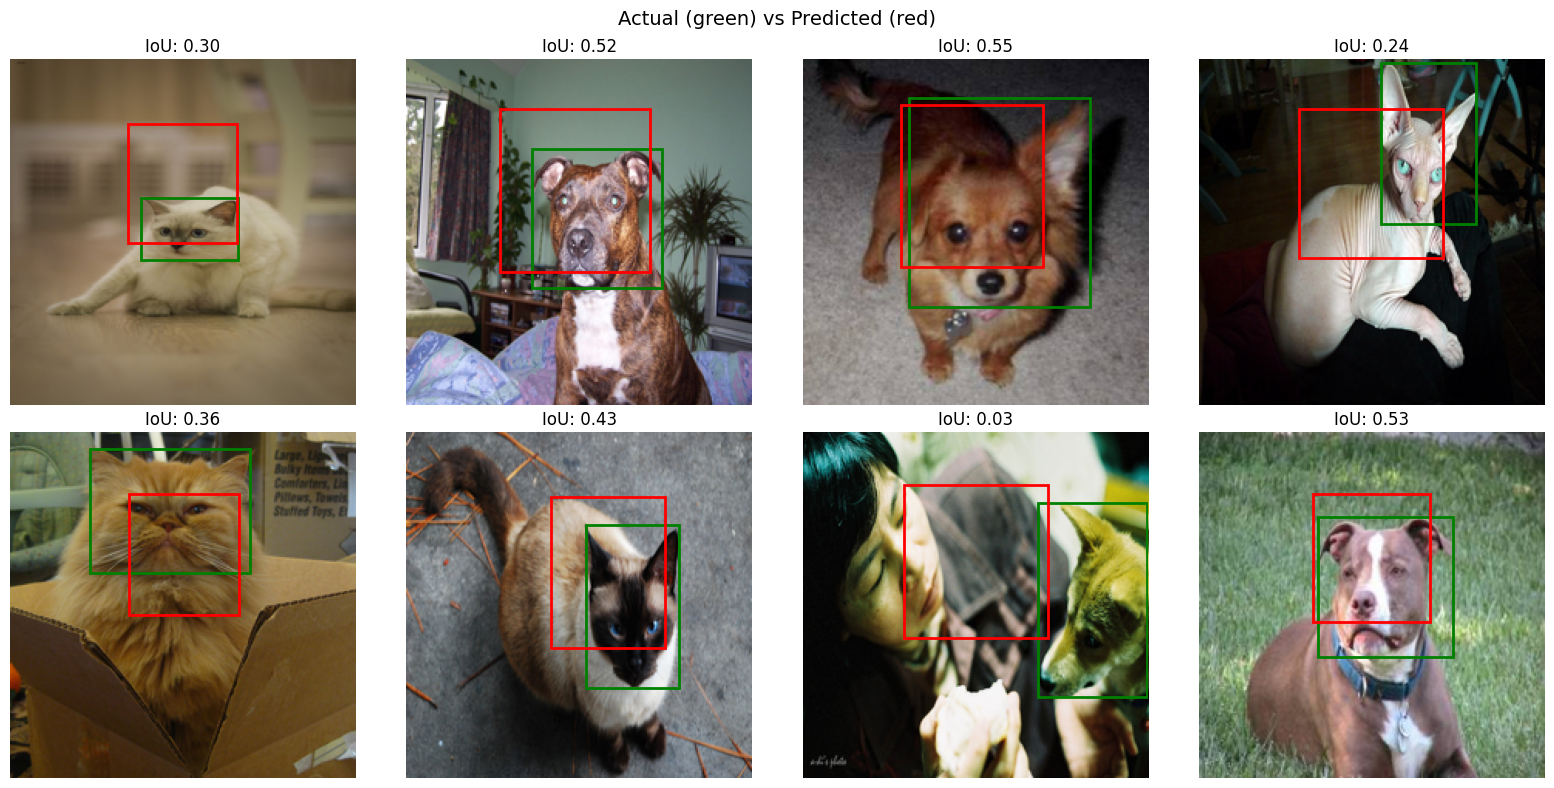

In [8]:
fig, axes  = plt.subplots(2, 4, figsize=(16, 8))
sample_idx = np.random.choice(len(X_test_imgs), 8, replace=False)

for ax, i in zip(axes.flatten(), sample_idx):
    ax.imshow(X_test_imgs[i])
    x, y, w, h = y_test[i]
    ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='g', facecolor='none'))
    px, py, pw, ph = y_pred_test[i]
    ax.add_patch(patches.Rectangle((px, py), pw, ph, linewidth=2, edgecolor='r', facecolor='none'))
    ax.set_title(f'IoU: {iou(y_test[i], y_pred_test[i]):.2f}')
    ax.axis('off')

plt.suptitle('Actual (green) vs Predicted (red)', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
os.makedirs('models', exist_ok=True)
joblib.dump(best, 'models/random_forest_pipeline.joblib')
print('Saved random_forest_pipeline.joblib to machine_learning/models/')

Saved random_forest_pipeline.joblib to machine_learning/models/


In [10]:
import platform
import xml.etree.ElementTree as ET
from datetime import datetime

def export_predictions_xml(y_pred, indices, split_name, model_name, best_params, out_path):
    root = ET.Element('predictions')
    root.set('model', model_name)
    root.set('n_test', str(len(indices)))

    meta_el = ET.SubElement(root, 'metadata')
    ET.SubElement(meta_el, 'timestamp').text = datetime.now().isoformat(timespec='seconds')

    hw_el = ET.SubElement(meta_el, 'hardware')
    ET.SubElement(hw_el, 'platform').text = platform.system()
    ET.SubElement(hw_el, 'os_version').text = platform.release()
    ET.SubElement(hw_el, 'machine').text = platform.machine()
    ET.SubElement(hw_el, 'processor').text = platform.processor() or platform.machine()

    hp_el = ET.SubElement(meta_el, 'hyperparams')
    ET.SubElement(hp_el, 'n_estimators').text = str(best_params['rf__n_estimators'])
    ET.SubElement(hp_el, 'max_depth').text = str(best_params['rf__max_depth'])
    ET.SubElement(hp_el, 'min_samples_leaf').text = str(best_params['rf__min_samples_leaf'])
    ET.SubElement(hp_el, 'pca_n_components').text = str(best_params['pca__n_components'])

    for i, idx in enumerate(indices):
        img_el = ET.SubElement(root, 'image')
        img_el.set('dataset_index', str(int(idx)))
        px, py, pw, ph = y_pred[i]
        bbox_el = ET.SubElement(img_el, 'predicted_bbox')
        ET.SubElement(bbox_el, 'x').text = f'{px:.4f}'
        ET.SubElement(bbox_el, 'y').text = f'{py:.4f}'
        ET.SubElement(bbox_el, 'width').text = f'{pw:.4f}'
        ET.SubElement(bbox_el, 'height').text = f'{ph:.4f}'

    tree = ET.ElementTree(root)
    ET.indent(tree, space='  ')
    tree.write(str(out_path), encoding='unicode', xml_declaration=True)
    print(f'Saved {split_name} predictions ({len(indices)} images) → {out_path}')

os.makedirs('predictions', exist_ok=True)
export_predictions_xml(y_pred_test,  test_idx,  'test',  'random_forest', search.best_params_, 'predictions/rf_predictions_test.xml')
export_predictions_xml(y_pred_train, train_idx, 'train', 'random_forest', search.best_params_, 'predictions/rf_predictions_train.xml')

Saved test predictions (738 images) → predictions/rf_predictions_test.xml
Saved train predictions (2580 images) → predictions/rf_predictions_train.xml
